In [1]:
import cv2
import numpy as np
from src.utils import ingaas_processing as ip
from src.utils import scanner_processing as scp
from pathlib import Path
import tomlkit
import matplotlib.pyplot as plt

resize = lambda x: cv2.resize(x, (x.shape[1], 766))
stretch = lambda x: ip.lin_stretch_img(x, 0.3, 99.7)
process = lambda x: stretch(resize(x))

In [2]:
datadir = Path("C://Users//jeppe//Desktop//Work Stuffs//Data Sets//LIPI_Paper//20260618_144430")
#datadir = Path("/home/jepero/Work/Code/Scans/Paper_Cloud_Cover/")
scanpath = list(datadir.glob("*.raw"))[0]
configpath = list(datadir.glob("*.toml"))[0]
calpath = "data/calibration.npz"

In [3]:
with configpath.open() as f:
    config = tomlkit.load(f)
speed = config["robot"]["speed"]/60 #mm/s
fps = config["camera"]["fps"] #frames/s
mod_freq = config["general"]["modulation_freq"]
pixel_pitch = 15/1000 #mm/pitch (image plane)

print(speed,fps,mod_freq,pixel_pitch)

41.666666666666664 300.001647 50 0.015


In [4]:
scan = scp.load_scan(scanpath,cal_path=calpath)
peaks,valleys = scp.get_extrema_scan(scan,  len(scan), skip=0, overlap=0, f_m=mod_freq, fps=fps)
frame_profile = scan.sum(axis=2)
print(np.unique(np.diff(peaks), return_counts=True))
print(np.unique(np.diff(valleys), return_counts=True))
print(np.unique(peaks-valleys))

Loading scan
Processing a .raw file
(14728, 512, 640)
Undistorting
(14728, 512, 640)
(array([6]), array([2453], dtype=int64))
(array([6]), array([2453], dtype=int64))
[-3]


In [5]:
# MATH
H_cam = 1045 #mm
focal = 6 #mm
speed = 2500/60 #mm/sec
pixel_pitch = 15/1000 #mm/pixel

frame_diff_high = np.abs(peaks-valleys).mean() #Frame between signal high and bg
frame_diff_low = 2
#FPS: frames/second
#pixel_pith: um/pixel

#Getting scaling factor
dpf = speed / fps  # mm/frame, on module
# dist_travel/cameraHeight=d/f
#doffset = 200 / H_cam * f  # distance in mm on image plane
dpf_f = dpf / H_cam * focal  # distance per frame in mm on image plane mm/frame
dpf_px = dpf_f / pixel_pitch  # distance per frame in px on image plane

print(dpf_px)
print(dpf_f)
print(dpf)

0.053162919193521535
0.000797443787902823
0.138888126393075


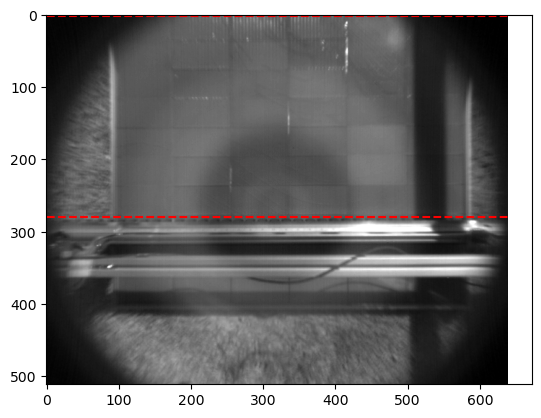

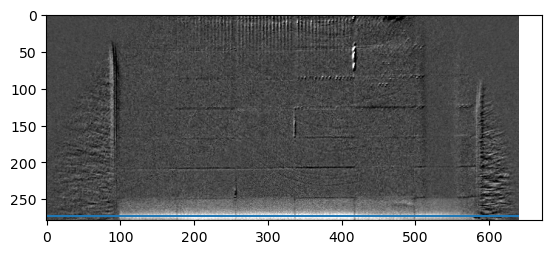

In [6]:
mask = np.zeros_like(scan[0], dtype=np.bool_)
mask_h_lower = 1
mask_h_upper = 280
# mask_v_lower = 100
# mask_v_upper = 580
mask[mask_h_lower:mask_h_upper, :] = True

index = 498
plt.imshow(stretch(scan[peaks[index]]), cmap="gray")
plt.hlines([mask_h_lower, mask_h_upper], xmin=0, xmax=640, color="red", linestyle="--")
plt.show()

peak_frames = scan[peaks][:,mask].reshape((len(peaks),-1,640)).astype(np.float32)
valley_frames = scan[valleys][:,mask].reshape((len(peaks),-1,640)).astype(np.float32)
plt.imshow(stretch(peak_frames[200]-valley_frames[200]), cmap="gray")
plt.hlines(273, 0, 640)

In [7]:
def get_offsets(frames):
    txs = [0]
    tys = [0]
    prev = frames[0]
    hann = cv2.createHanningWindow(prev.shape[::-1], cv2.CV_32F)
    for frame in frames[1:]:
        (tx,ty), _ = cv2.phaseCorrelate(prev, frame, window=hann)
        txs.append(tx)
        tys.append(ty)
        prev = frame

    tys = np.cumsum(tys)
    txs = np.cumsum(txs)
    return txs, tys

def get_frame_weights(tys):
    A = int(tys.max())+1

    weights = 1-np.abs(np.arange(0,A).reshape(-1,1) - tys)
    weights[weights<0] = 0

    return weights

def stitch_frames(frames, line, offsets_y=None, weights=None):
    if offsets_y is None and weights is None:
        txs,offsets_y = get_offsets(frames)
    if weights is None:
        weights = get_frame_weights(offsets_y)
    return np.dot(weights,frames[:,line]) / (np.sum(weights,axis=1).reshape((-1,1))+1E-5)

In [8]:
extrema = np.empty(2*len(peaks), dtype=peaks.dtype)
print(extrema.shape)
extrema[::2] = peaks
extrema[1::2] = valleys

alternating_frames = scan[extrema][:,mask].reshape((len(extrema),-1,640)).astype(np.float32)
txs, tys = get_offsets(alternating_frames)

p2p_offsets = get_offsets(peak_frames)
v2v_offsets = get_offsets(valley_frames)
p2v_offsets = get_offsets(alternating_frames)

(4908,)


In [9]:
print(p2p_offsets[1], p2v_offsets[1][::2])

[ 0.00000000e+00 -1.44287934e-01 -2.98524554e-02 ...  7.37677574e+02
  7.37617514e+02  7.37795789e+02] [ 0.00000000e+00 -1.40350968e-01 -2.90888144e-02 ...  7.41251014e+02
  7.41177658e+02  7.41341239e+02]


In [10]:
L = len(peaks)
lom = 272
SL = scan[peaks,lom]
BL = scan[valleys,lom]

peak_stitch = stitch_frames(peak_frames, lom)
valley_stitch = stitch_frames(valley_frames, lom)



In [11]:
print(peaks[0])
print(valleys[0])

3
6


In [12]:
import numpy as np, scipy.sparse as sp
from scipy.sparse.linalg import splu

def reconstruct(frames, offsets, ridge=1e-9):
    # frames: (K, 5, W); offsets: (K,) in true-pixel units, offsets[0] = 0
    K, L, W = frames.shape
    n = np.floor(offsets).astype(int)
    d = offsets - n
    N = n.max() + L + 1                       # true rows (last row is weakly constrained)
    m = (n[:, None] + np.arange(L)).ravel()   # true row index for each measured row
    dd = np.repeat(d, L)
    r = np.arange(K * L)
    A = sp.csr_matrix(
        (np.r_[1 - dd, dd], (np.r_[r, r], np.r_[m, m + 1])), shape=(K * L, N))
    AtA = (A.T @ A + ridge * sp.eye(N)).tocsc()
    rhs = A.T @ frames.reshape(K * L, W)      # (N, W)
    X = splu(AtA).solve(rhs)
    return X[:-1]     # drop the weakest last row

27.143094795869615 741.3968563625936
-0.33


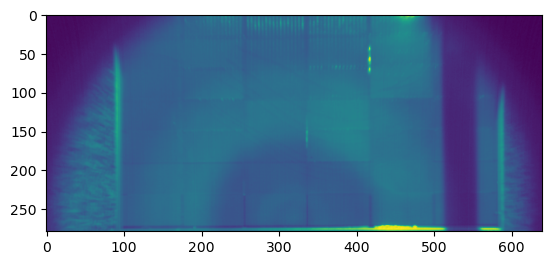

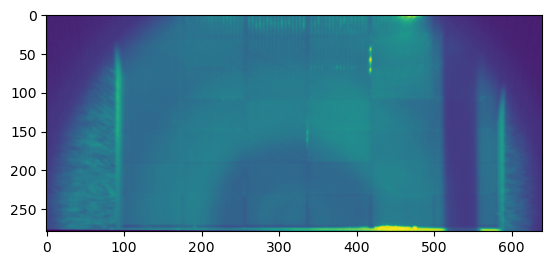

(2454, 1, 640)
Rotated


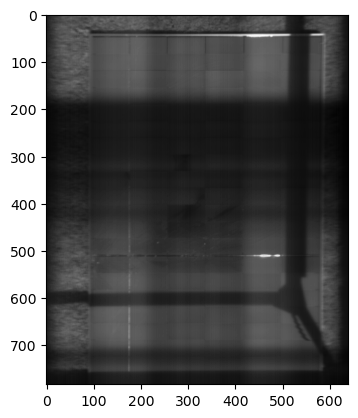

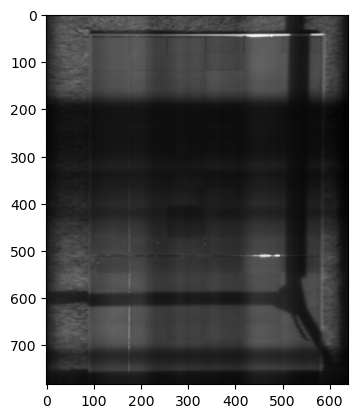

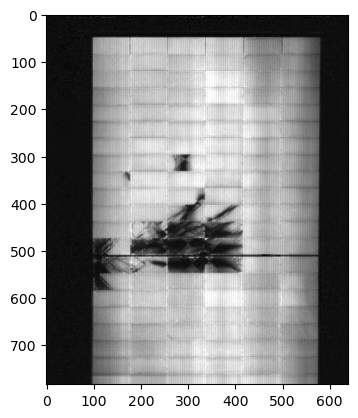

Spooky regresssion


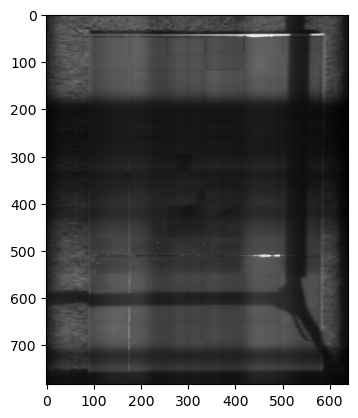

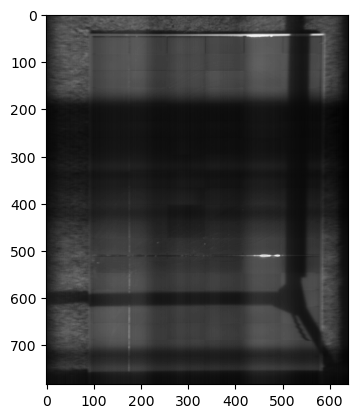

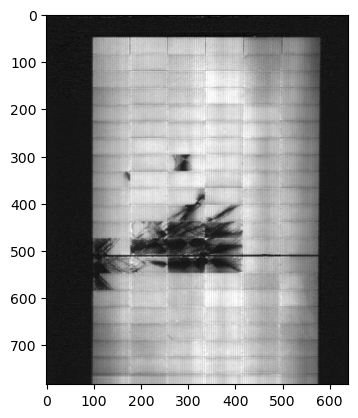

Spookier regressions


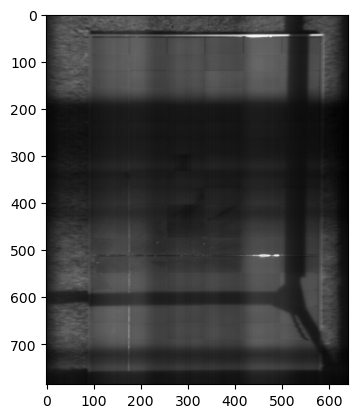

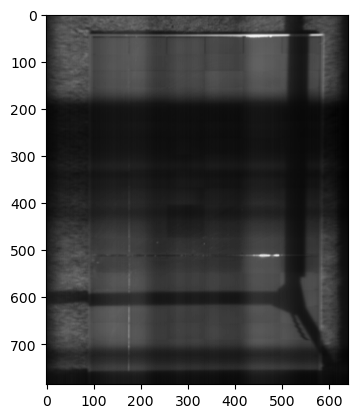

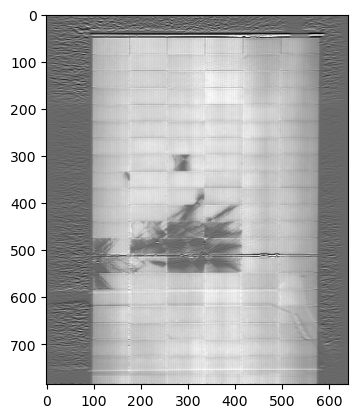

In [16]:
y=txs[-1]
x=tys[-1]

image = alternating_frames[300]

# Get the image dimensions
height, width = image.shape

# Define the rotation center
center = (width // 2, 512 // 2)

# Define the rotation angle
print(y,x)
# = -10*np.arctan(y/x)
angle = -0.33
print(angle)

# Define the scaling factor
scale = 1.0  # No scaling

# Get the rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)

# Perform the rotation
rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))

plt.imshow(image)
plt.show()
plt.imshow(rotated_image)
plt.show()

rotated_frames = np.zeros_like(alternating_frames)

for i,frame in enumerate(alternating_frames):
    rotated_frames[i] = cv2.warpAffine(frame, rotation_matrix, (width, height))
#
# weights = get_frame_weights(tys)
# weights_peaks = weights[:,::2]
# weights_valleys = weights[:,1::2]
#
# peak_stitch_v2 = np.dot(weights_peaks,peak_frames[:,lom]) / (np.sum(weights_peaks,axis=1).reshape((-1,1))+1E-5)
# valley_stitch_v2 = np.dot(weights_valleys,valley_frames[:,lom]) / (np.sum(weights_valleys,axis=1).reshape((-1,1))+1E-5)

peak_offset = 6*dpf_px*np.arange(0, len(peaks))
valley_offsets = peak_offset+3*dpf_px

peak_stitch_test = stitch_frames(peak_frames, lom, offsets_y=peak_offset)
valley_stitch_test = stitch_frames(valley_frames, lom, offsets_y=valley_offsets)

peak_stitch_test_rot = stitch_frames(rotated_frames[::2], lom, offsets_y=peak_offset)
valley_stitch_test_rot = stitch_frames(rotated_frames[1::2], lom, offsets_y=valley_offsets)

print(rotated_frames[::2, lom:lom+1].shape)
regression_test_peaks  = reconstruct(rotated_frames[::2, lom:lom+1], offsets=peak_offset)
regression_test_valley = reconstruct(rotated_frames[1::2, lom:lom+1], offsets=valley_offsets)

def plotter(peak, valley, name):
    plt.imshow(peak, cmap="gray")
    plt.show()

    plt.imshow(valley, cmap="gray")
    plt.show()

    plt.imshow(stretch(peak-valley), cmap="gray")
    plt.show()

    plt.imsave(datadir.joinpath(name+".png"), stretch(peak-valley), cmap="gray")

# print("Version 1")
# plotter(peak_stitch, valley_stitch)

# print("Version 2")
# plotter(peak_stitch_v2, valley_stitch_v2, "PhaseCorr")
#
# print("Test")
# plotter(peak_stitch_test, valley_stitch_test, "CalcOffset")

print("Rotated")
plotter(peak_stitch_test_rot, valley_stitch_test_rot, "CalcOffsetAndRot")

print("Spooky regresssion")
plotter(regression_test_peaks, regression_test_valley, "RegressionTest")

print("Spookier regressions")
plotter(reg_test_v2_peaks, reg_test_v2_valley, "RegressionTest2")

# print("Subtracted")
# plotter(peak_stitch_test_rot-peak_stitch_test, valley_stitch_test_rot-valley_stitch_test, "RotChange")

In [14]:
window = cv2.createHanningWindow(peak_stitch.shape[::-1], cv2.CV_64F)
(tx,ty),_ = cv2.phaseCorrelate(peak_stitch, valley_stitch, window=window)
print(tx,ty)

error: OpenCV(4.10.0) C:\b\abs_daut97tdpo\croot\opencv-suite_1722029138522\work\modules\imgproc\src\phasecorr.cpp:528: error: (-215:Assertion failed) src1.size == src2.size in function 'cv::phaseCorrelate'


In [ ]:
plt.imshow(cv2.resize(SL, (640,peak_stitch.shape[0])),cmap="gray")
plt.show()